In [17]:
# Import the libraries needed for the distribution analysis.
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Load the raw HR attrition dataset.
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

# Keep every numeric dataframe column so the analysis is complete.
numeric_features = df.select_dtypes(include="number").columns.tolist()

feature_summary = (
    df[numeric_features]
    .describe()
    .T
    .assign(
        Missing=df[numeric_features].isna().sum(),
        UniqueValues=df[numeric_features].nunique(dropna=True),
    )
    [["count", "Missing", "UniqueValues", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)

print(f"Dataset shape: {df.shape}")
print(f"Numeric features: {len(numeric_features)}")
display(feature_summary.round(2))

Dataset shape: (1470, 35)
Numeric features: 26


,count,Missing,UniqueValues,mean,std,min,25%,50%,75%,max
Age,1470.0,0,43,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,0,886,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,0,29,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,0,5,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,0,1,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,0,1470,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,0,4,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,0,71,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,0,4,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,0,5,2.06,1.11,1.0,1.00,2.0,3.00,5.0


In [18]:
numeric_features.remove("EmployeeCount")
numeric_features.remove("StandardHours")
numeric_features.remove("PerformanceRating")

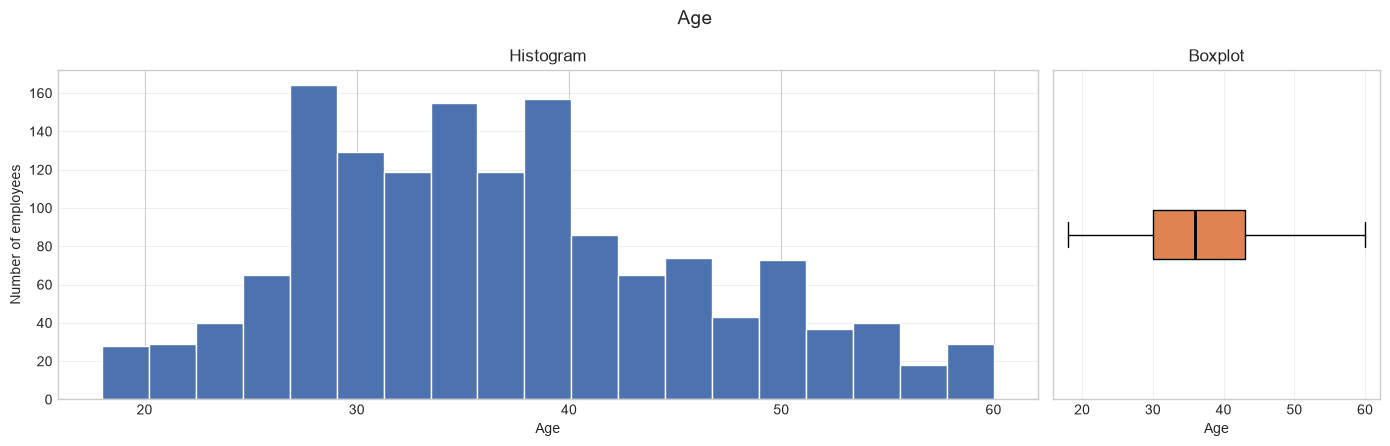

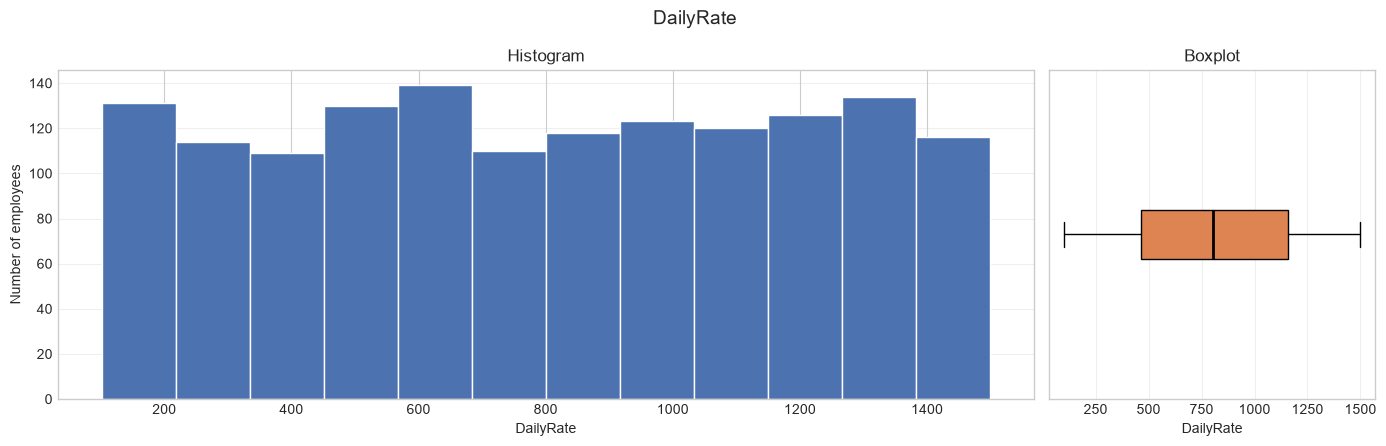

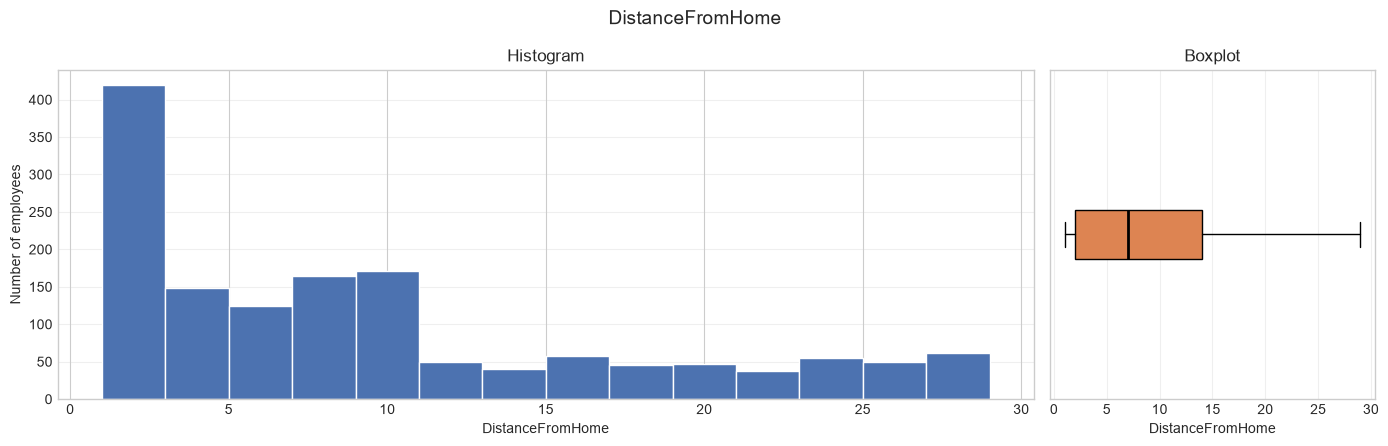

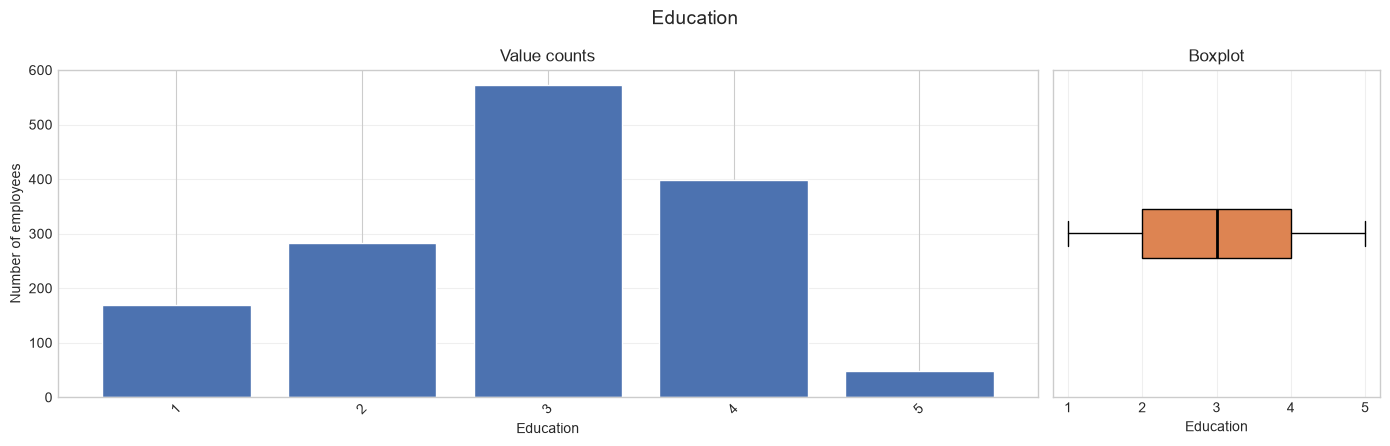

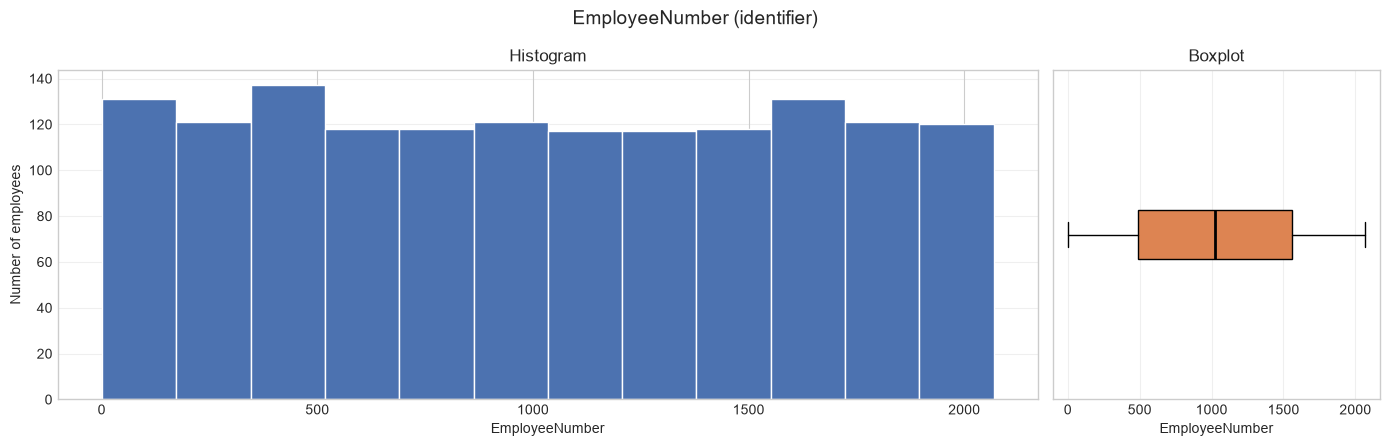

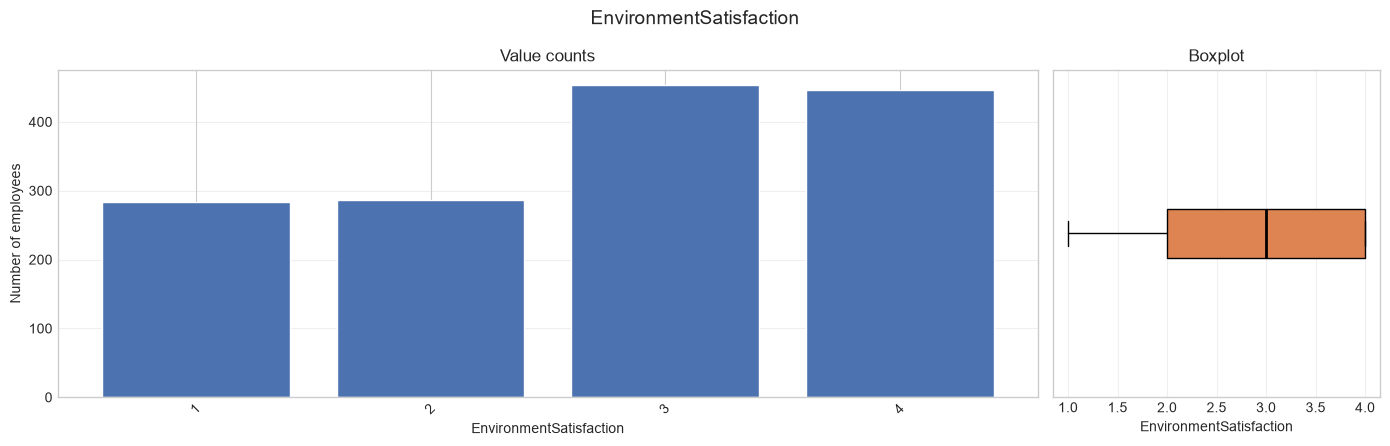

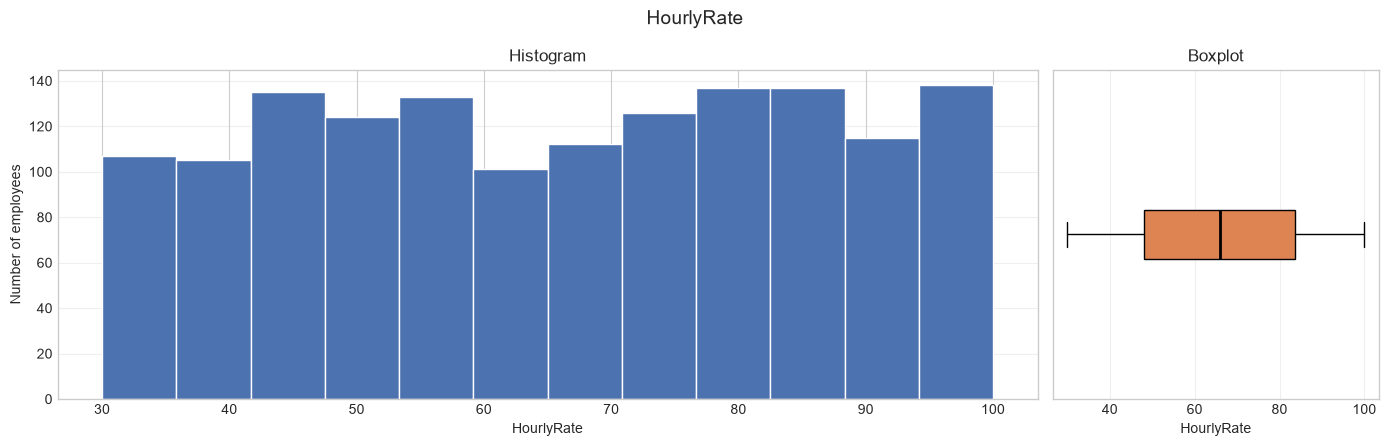

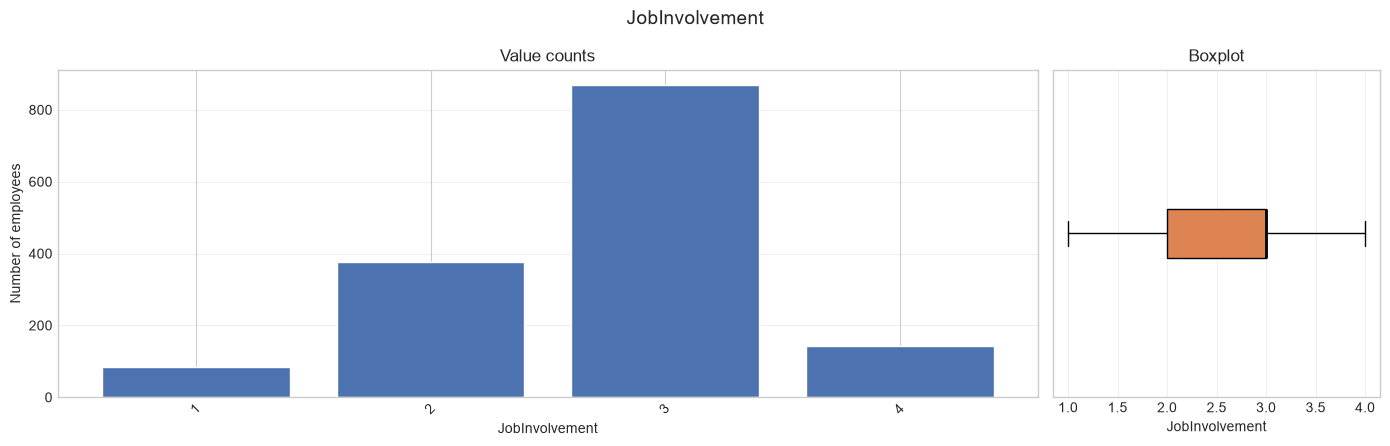

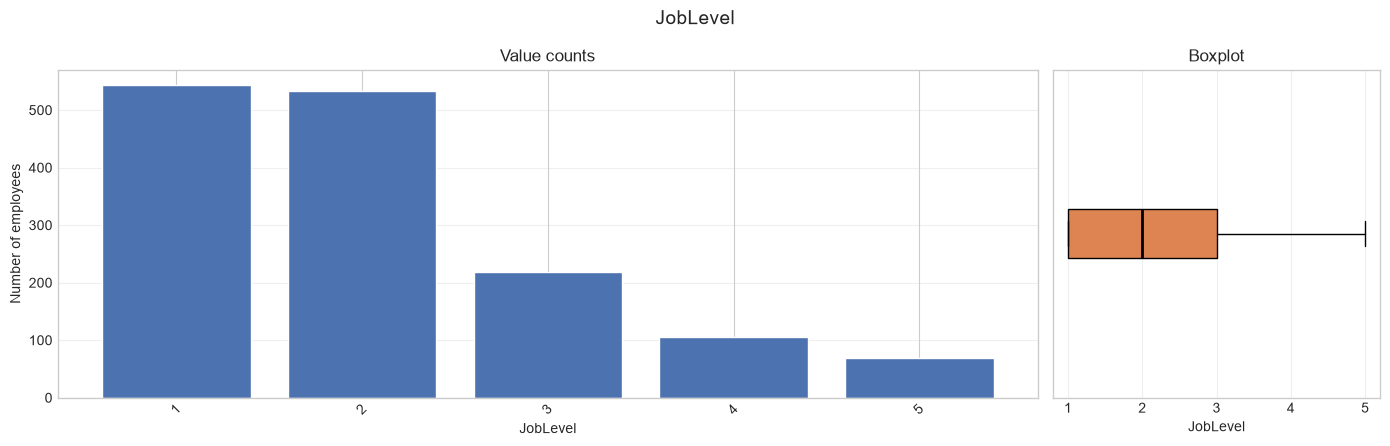

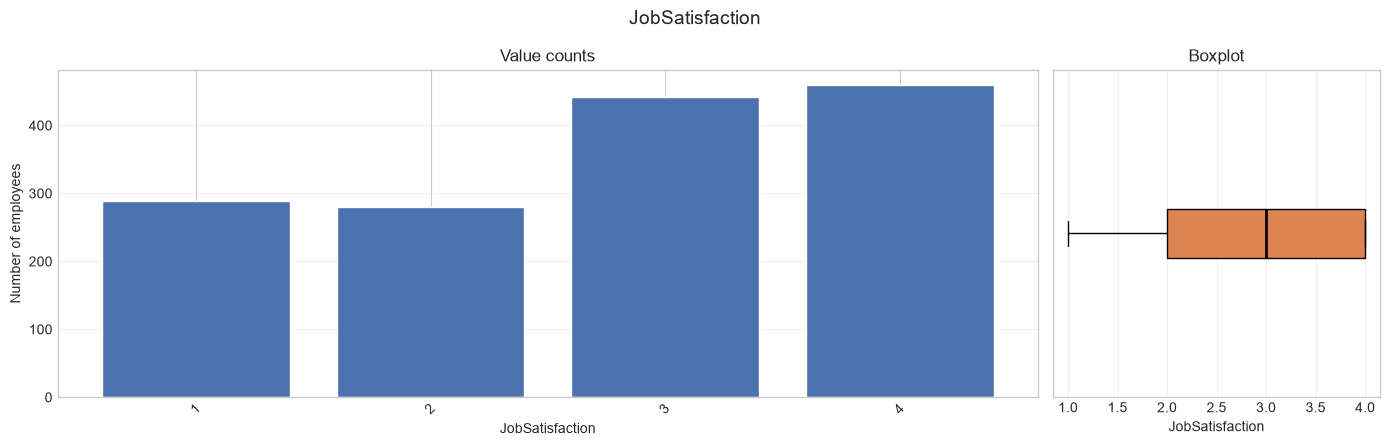

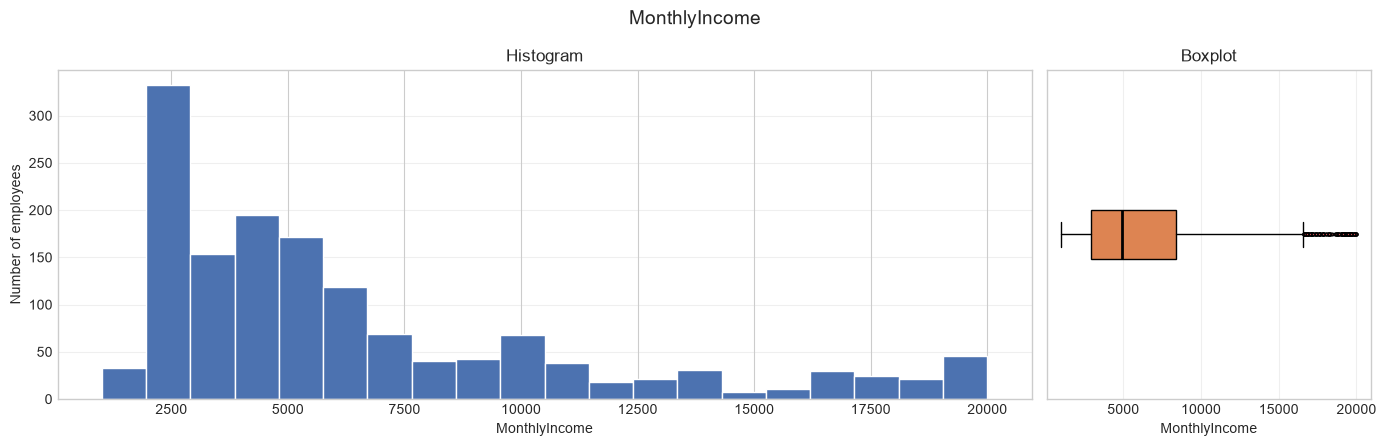

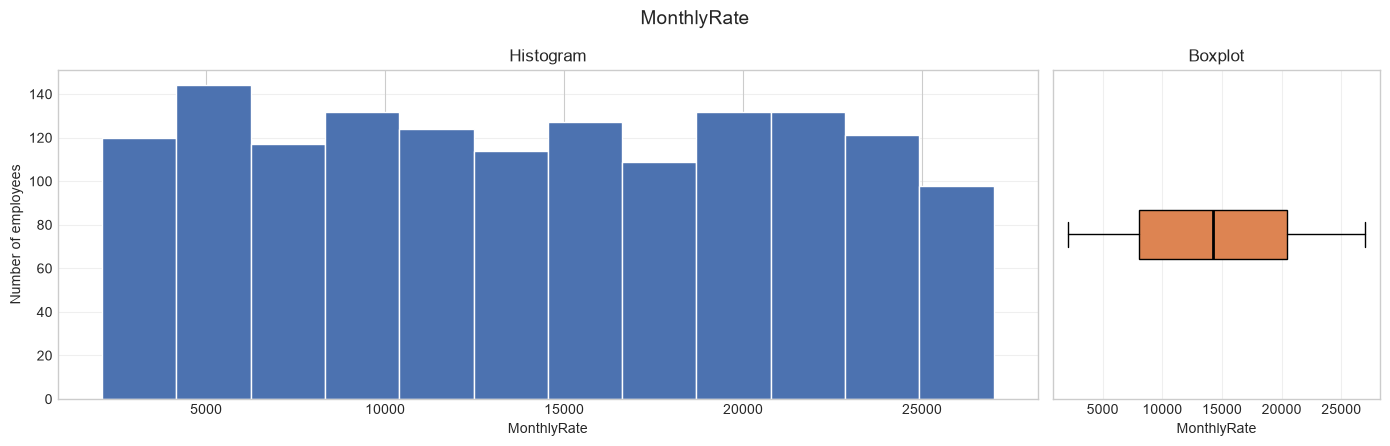

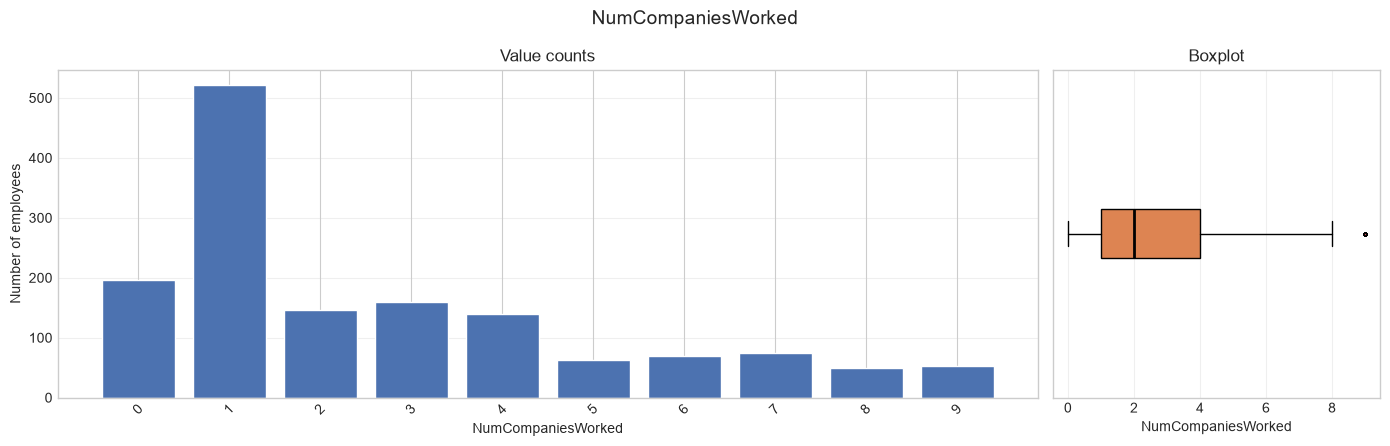

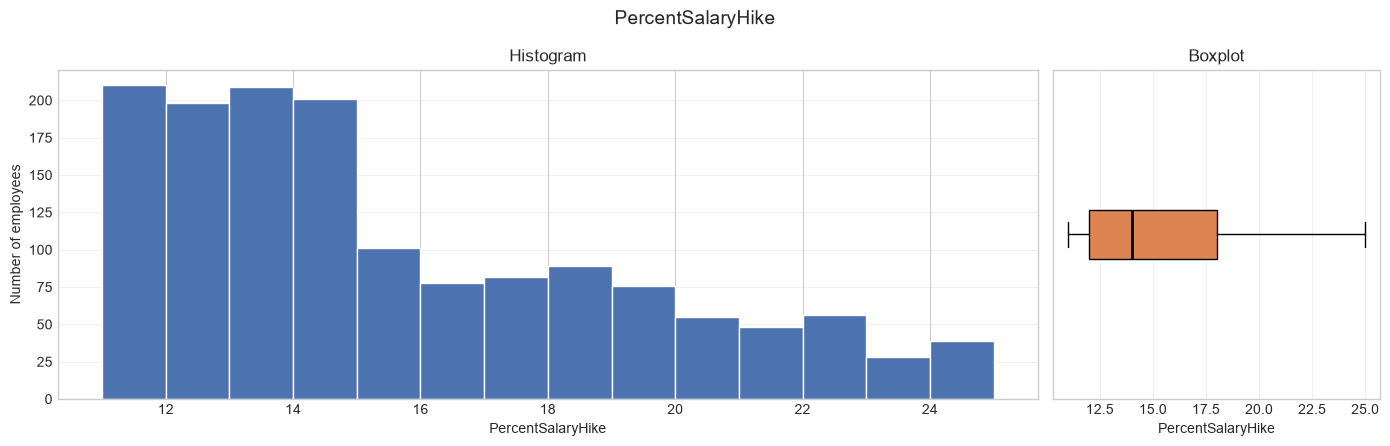

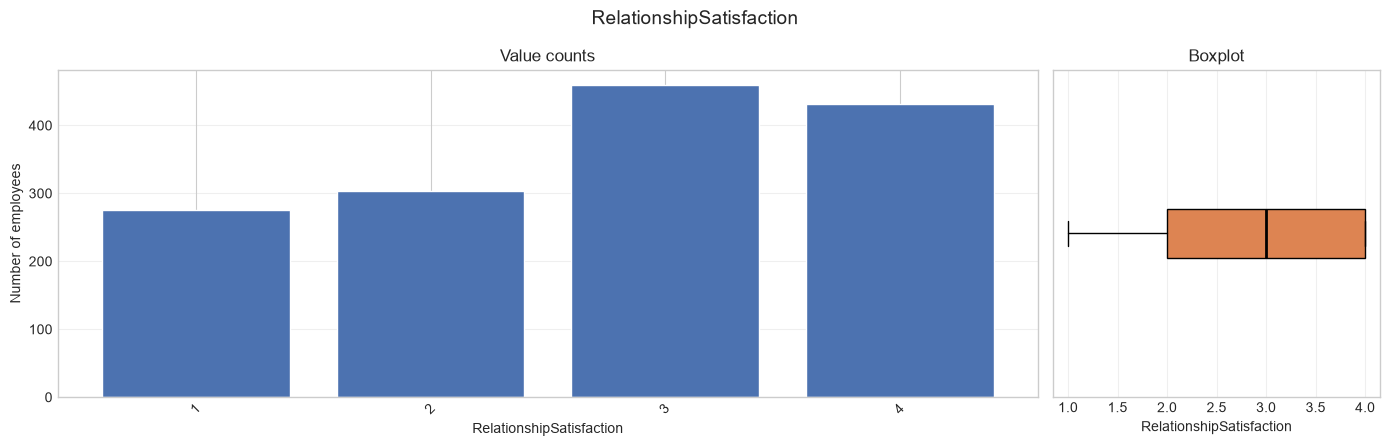

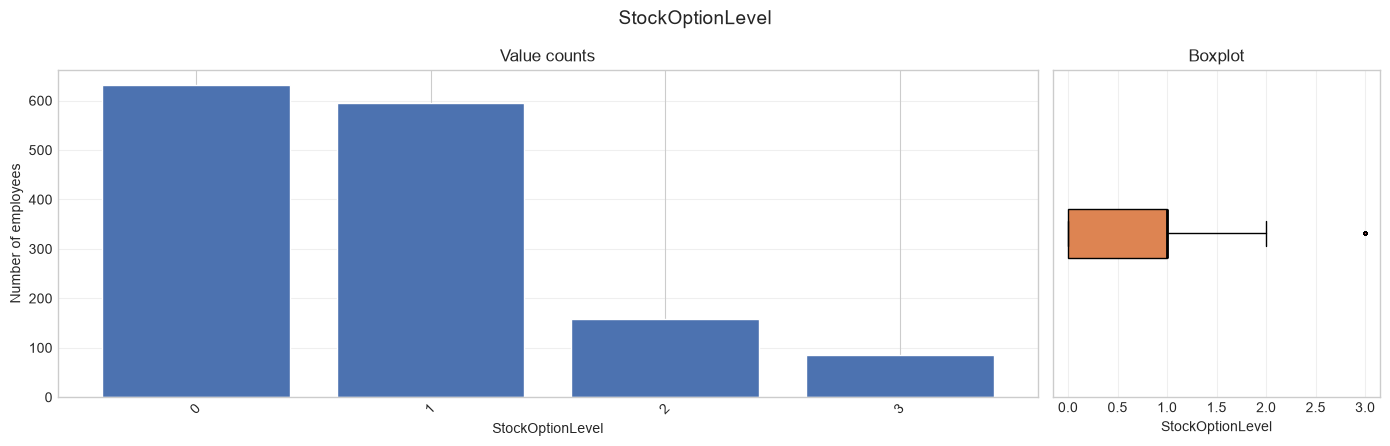

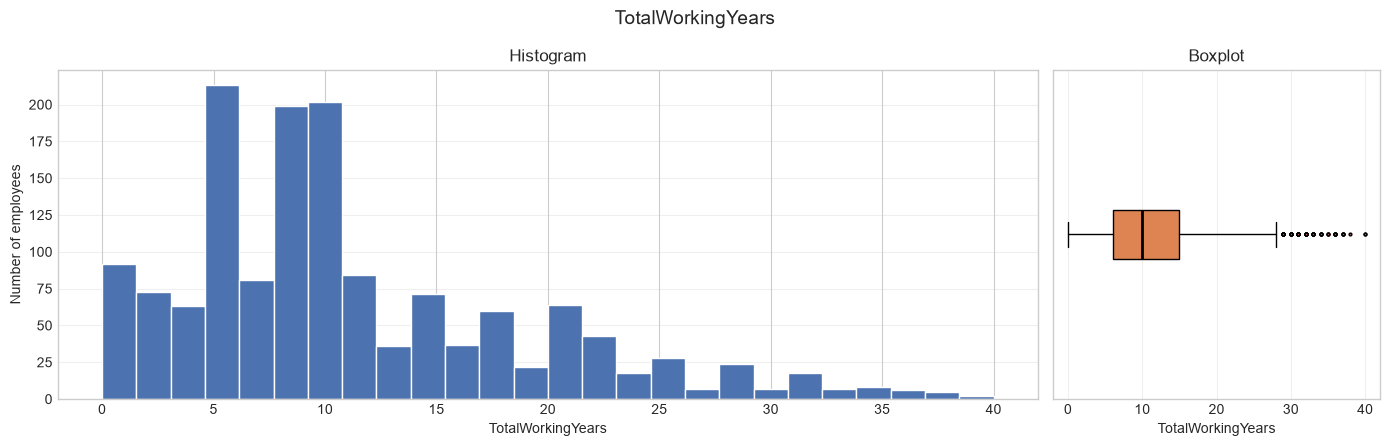

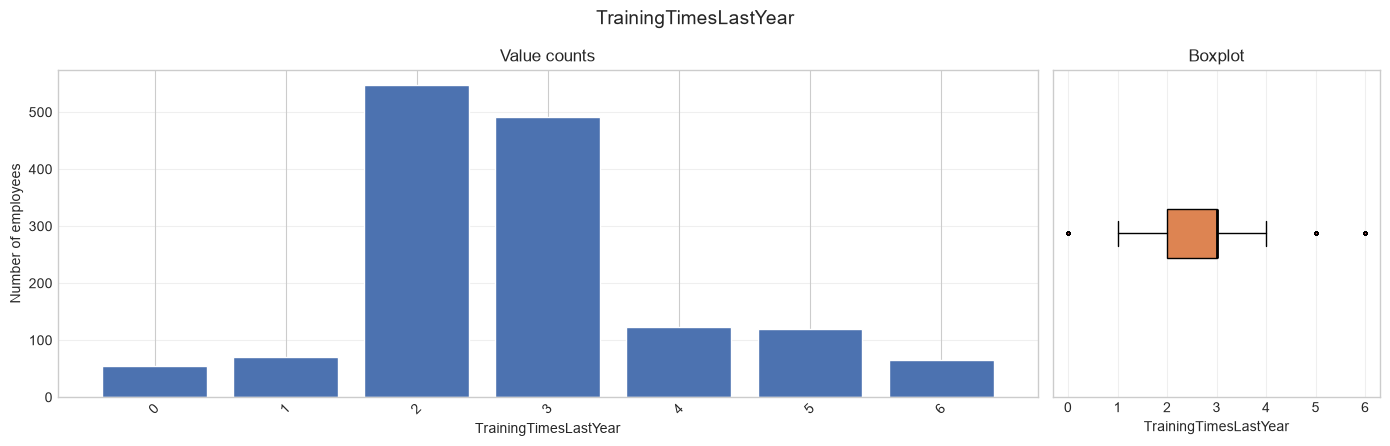

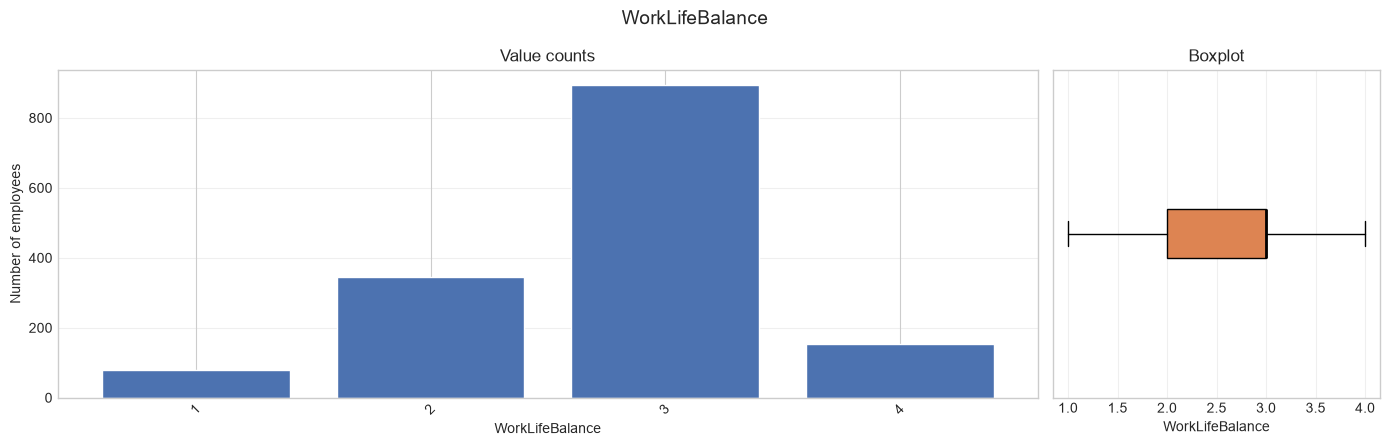

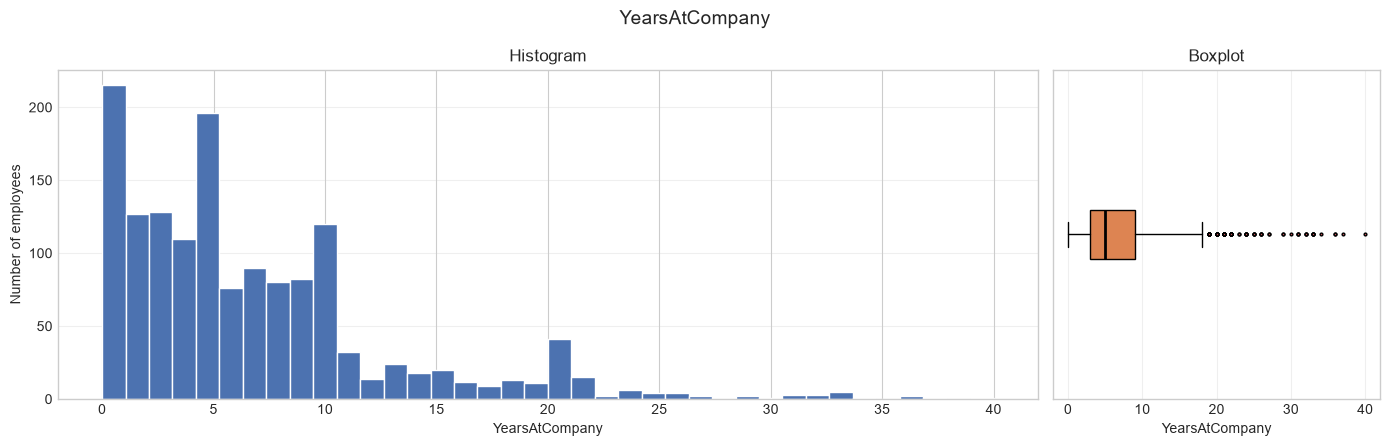

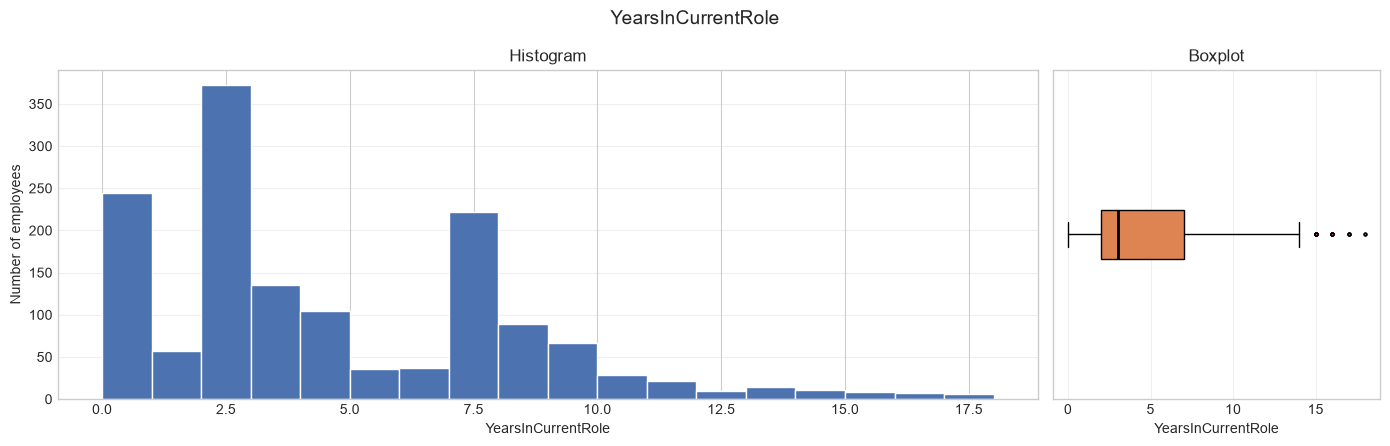

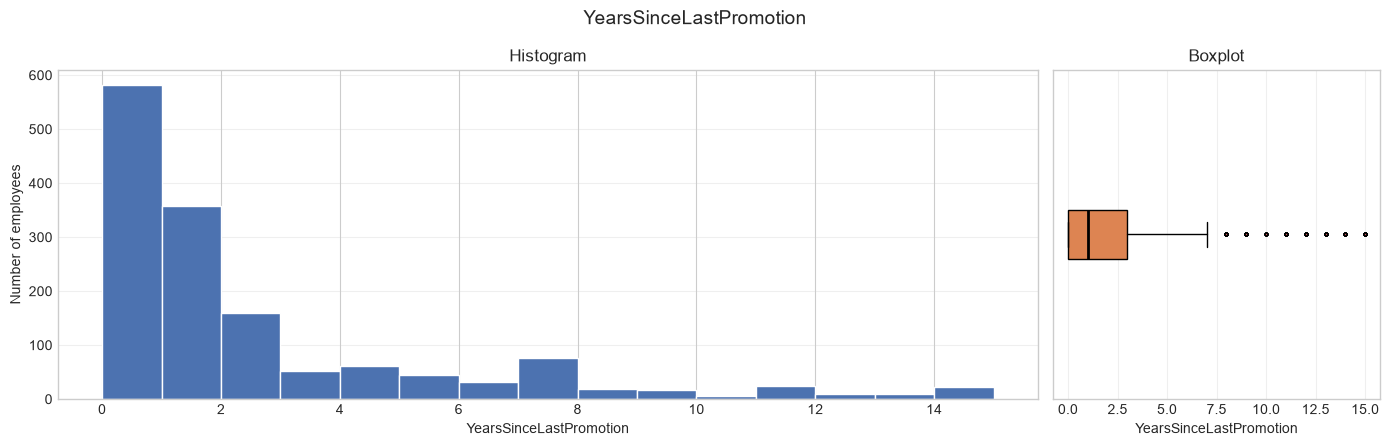

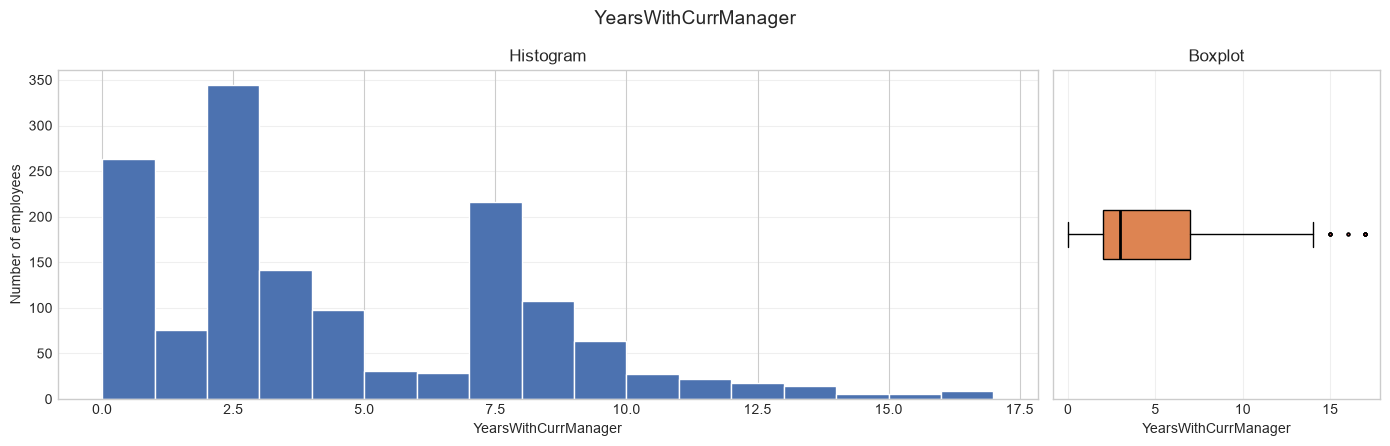

In [19]:
# Create one distribution figure for every numeric feature.
# Low-cardinality numeric columns are treated as discrete values and shown with count bars.
# Higher-cardinality columns are shown with histograms because binning reveals their shape.
for feature in numeric_features:
    values = df[feature].dropna()
    unique_count = values.nunique()
    is_identifier = feature == "EmployeeNumber"
    is_constant = unique_count <= 1
    is_discrete = unique_count <= 10

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4.5),
        gridspec_kw={"width_ratios": [3, 1]}
    )

    if is_discrete:
        counts = values.value_counts().sort_index()
        axes[0].bar(
            counts.index.astype(str),
            counts.values,
            color="#4c72b0",
            edgecolor="white"
        )
        axes[0].set_xlabel(feature)
        axes[0].set_ylabel("Number of employees")
        axes[0].tick_params(axis="x", rotation=45)
    else:
        axes[0].hist(
            values,
            bins="fd",
            color="#4c72b0",
            edgecolor="white"
        )
        axes[0].set_xlabel(feature)
        axes[0].set_ylabel("Number of employees")

    axes[0].set_title("Value counts" if is_discrete else "Histogram")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].boxplot(
        values,
        orientation="horizontal",
        patch_artist=True,
        boxprops={"facecolor": "#dd8452"},
        medianprops={"color": "black", "linewidth": 2},
        flierprops={"marker": ".", "markerfacecolor": "#c44e52", "markersize": 4}
    )
    axes[1].set_xlabel(feature)
    axes[1].set_yticks([])
    axes[1].set_title("Boxplot")
    axes[1].grid(axis="x", alpha=0.3)

    notes = []
    if is_identifier:
        notes.append("identifier")
    if is_constant:
        notes.append("constant column")
    if notes:
        fig.suptitle(f"{feature} ({', '.join(notes)})", fontsize=14)
    else:
        fig.suptitle(feature, fontsize=14)
    fig.tight_layout()
    plt.show()
    plt.close(fig)